In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

# ***EDA parte 1***

In [ ]:
df = pd.read_csv("frequency_response.csv")
print(df.head())

                      device_name device_type eq_variant  \
0      Aalto Speakers Aalto 1 EVO     speaker     autoeq   
1      Aalto Speakers Aalto 1 EVO     speaker     autoeq   
2  Aalto Speakers Aalto 3 Passive     speaker     autoeq   
3       Acoustic Energy AE100 Mk2     speaker     autoeq   
4                        Adam A4V     speaker   dbx-1215   

              data_source  score_with_eq  f_20.0Hz  f_20.6Hz  f_21.2Hz  \
0  Vendors-Aalto Speakers           6.73 -2.993797 -2.978844 -2.962565   
1  Vendors-Aalto Speakers           6.73 -2.993797 -2.978844 -2.962565   
2  Vendors-Aalto Speakers           7.54 -1.355612 -1.261096 -1.163404   
3        ErinsAudioCorner           6.42 -2.353568 -2.309130 -2.261371   
4                     ASR           4.03 -0.741531 -0.722319 -0.701286   

   f_21.8Hz  f_22.4Hz  ...  f_15550Hz  f_15991Hz  f_16444Hz  f_16910Hz  \
0 -2.944808 -2.925396  ...  -3.401413  -3.378654  -3.357034  -3.336591   
1 -2.944808 -2.925396  ...  -3.401413  -3.3786

In [ ]:
df.shape
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3280 entries, 0 to 3279
Columns: 253 entries, device_name to f_20000Hz
dtypes: float64(249), object(4)
memory usage: 6.3+ MB


,count,mean,std,min,25%,50%,75%,max
score_with_eq,2616.0,4.859702,1.619203,0.100000,3.770000,5.080000,6.060000,8.810000
f_20.0Hz,3280.0,-1.610443,2.948823,-96.243110,-2.251888,-0.687259,-0.382480,1.341870
f_20.6Hz,3280.0,-1.586295,2.953188,-95.764388,-2.220454,-0.651787,-0.344134,1.413307
f_21.2Hz,3280.0,-1.559076,2.958006,-95.286075,-2.211047,-0.610195,-0.303434,1.488683
f_21.8Hz,3280.0,-1.529602,2.964111,-94.808197,-2.194040,-0.599923,-0.263792,1.568271
...,...,...,...,...,...,...,...,...
f_17883Hz,3280.0,-2.244781,2.324694,-61.311758,-3.343819,-1.146925,-0.673716,1.384304
f_18390Hz,3280.0,-2.216996,2.286611,-62.133133,-3.295252,-1.161717,-0.683185,0.891961
f_18912Hz,3280.0,-2.188855,2.253201,-63.045169,-3.234622,-1.157715,-0.688408,0.596662
f_19448Hz,3280.0,-2.161754,2.224909,-64.071722,-3.189144,-1.164379,-0.693279,0.395904


In [ ]:
df.columns.tolist()

['device_name',
 'device_type',
 'eq_variant',
 'data_source',
 'score_with_eq',
 'f_20.0Hz',
 'f_20.6Hz',
 'f_21.2Hz',
 'f_21.8Hz',
 'f_22.4Hz',
 'f_23.0Hz',
 'f_23.7Hz',
 'f_24.3Hz',
 'f_25.0Hz',
 'f_25.7Hz',
 'f_26.5Hz',
 'f_27.2Hz',
 'f_28.0Hz',
 'f_28.8Hz',
 'f_29.6Hz',
 'f_30.4Hz',
 'f_31.3Hz',
 'f_32.2Hz',
 'f_33.1Hz',
 'f_34.0Hz',
 'f_35.0Hz',
 'f_36.0Hz',
 'f_37.0Hz',
 'f_38.1Hz',
 'f_39.1Hz',
 'f_40.2Hz',
 'f_41.4Hz',
 'f_42.6Hz',
 'f_43.8Hz',
 'f_45.0Hz',
 'f_46.3Hz',
 'f_47.6Hz',
 'f_48.9Hz',
 'f_50.3Hz',
 'f_51.8Hz',
 'f_53.2Hz',
 'f_54.7Hz',
 'f_56.3Hz',
 'f_57.9Hz',
 'f_59.5Hz',
 'f_61.2Hz',
 'f_63.0Hz',
 'f_64.7Hz',
 'f_66.6Hz',
 'f_68.5Hz',
 'f_70.4Hz',
 'f_72.4Hz',
 'f_74.5Hz',
 'f_76.6Hz',
 'f_78.7Hz',
 'f_81.0Hz',
 'f_83.3Hz',
 'f_85.6Hz',
 'f_88.1Hz',
 'f_90.6Hz',
 'f_93.1Hz',
 'f_95.8Hz',
 'f_98.5Hz',
 'f_101Hz',
 'f_104Hz',
 'f_107Hz',
 'f_110Hz',
 'f_113Hz',
 'f_116Hz',
 'f_120Hz',
 'f_123Hz',
 'f_127Hz',
 'f_130Hz',
 'f_134Hz',
 'f_138Hz',
 'f_142Hz',
 'f_146Hz

In [ ]:
df.isnull().sum()


,0
device_name,0
device_type,0
eq_variant,0
data_source,375
score_with_eq,664
...,...
f_17883Hz,0
f_18390Hz,0
f_18912Hz,0
f_19448Hz,0


In [ ]:
df.duplicated().sum()

np.int64(51)

In [ ]:
highest_average = df.mean(numeric_only=True).max()
print(f"The highest average among all numerical columns is: {highest_average}")

The highest average among all numerical columns is: 4.859701834862385


In [ ]:
#Detectar columnas de frecuencia
freq_cols = [c for c in df.columns if c.startswith("f_")]
len(freq_cols)

248

In [ ]:
#Missing values
df.isnull().sum().sort_values(ascending=False)

,0
score_with_eq,664
data_source,375
device_name,0
eq_variant,0
device_type,0
...,...
f_17883Hz,0
f_18390Hz,0
f_18912Hz,0
f_19448Hz,0


In [ ]:
#tipos de datos
df[freq_cols] = df[freq_cols].astype(float)
df[freq_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
f_20.0Hz,3280.0,-1.610443,2.948823,-96.243110,-2.251888,-0.687259,-0.382480,1.341870
f_20.6Hz,3280.0,-1.586295,2.953188,-95.764388,-2.220454,-0.651787,-0.344134,1.413307
f_21.2Hz,3280.0,-1.559076,2.958006,-95.286075,-2.211047,-0.610195,-0.303434,1.488683
f_21.8Hz,3280.0,-1.529602,2.964111,-94.808197,-2.194040,-0.599923,-0.263792,1.568271
f_22.4Hz,3280.0,-1.494760,2.970903,-94.330778,-2.178952,-0.556566,-0.229592,1.652370
...,...,...,...,...,...,...,...,...
f_17883Hz,3280.0,-2.244781,2.324694,-61.311758,-3.343819,-1.146925,-0.673716,1.384304
f_18390Hz,3280.0,-2.216996,2.286611,-62.133133,-3.295252,-1.161717,-0.683185,0.891961
f_18912Hz,3280.0,-2.188855,2.253201,-63.045169,-3.234622,-1.157715,-0.688408,0.596662
f_19448Hz,3280.0,-2.161754,2.224909,-64.071722,-3.189144,-1.164379,-0.693279,0.395904


In [ ]:
# Duplicados exactos
df.duplicated().sum()

np.int64(51)

In [ ]:
# Duplicados por device_name
df[df.duplicated(subset=["device_type"], keep=False)]

,device_name,device_type,eq_variant,data_source,score_with_eq,f_20.0Hz,f_20.6Hz,f_21.2Hz,f_21.8Hz,f_22.4Hz,...,f_15550Hz,f_15991Hz,f_16444Hz,f_16910Hz,f_17390Hz,f_17883Hz,f_18390Hz,f_18912Hz,f_19448Hz,f_20000Hz
0,Aalto Speakers Aalto 1 EVO,speaker,autoeq,Vendors-Aalto Speakers,6.73,-2.993797,-2.978844,-2.962565,-2.944808,-2.925396,...,-3.401413,-3.378654,-3.357034,-3.336591,-3.317363,-3.299390,-3.282712,-3.267375,-3.253425,-3.240916
1,Aalto Speakers Aalto 1 EVO,speaker,autoeq,Vendors-Aalto Speakers,6.73,-2.993797,-2.978844,-2.962565,-2.944808,-2.925396,...,-3.401413,-3.378654,-3.357034,-3.336591,-3.317363,-3.299390,-3.282712,-3.267375,-3.253425,-3.240916
2,Aalto Speakers Aalto 3 Passive,speaker,autoeq,Vendors-Aalto Speakers,7.54,-1.355612,-1.261096,-1.163404,-1.063025,-0.960602,...,-3.169787,-3.150633,-3.132427,-3.115205,-3.099001,-3.083849,-3.069786,-3.056850,-3.045082,-3.034529
3,Acoustic Energy AE100 Mk2,speaker,autoeq,ErinsAudioCorner,6.42,-2.353568,-2.309130,-2.261371,-2.210040,-2.154877,...,-5.632660,-5.450971,-5.253803,-5.044111,-4.825325,-4.601241,-4.375921,-4.153601,-3.938619,-3.735362
4,Adam A4V,speaker,dbx-1215,ASR,4.03,-0.741531,-0.722319,-0.701286,-0.678910,-0.656091,...,-1.162538,-1.176618,-1.152643,-1.100235,-1.045046,-1.001133,-0.969809,-0.948122,-0.933054,-0.922433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3275,ZMF Atrium Closed,headphone,score,NaN,NaN,-4.315657,-4.355070,-4.396560,-4.440229,-4.486180,...,-3.658731,-3.651179,-3.644250,-3.637905,-3.632111,-3.626842,-3.622073,-3.617787,-3.613968,-3.610606
3276,ZMF Bokeh,headphone,flat,NaN,NaN,-6.030342,-6.032161,-6.034093,-6.036147,-6.038331,...,-2.607809,-2.909883,-3.213724,-3.516656,-3.816000,-4.109038,-4.392971,-4.664881,-4.921686,-5.160107
3277,ZMF Bokeh,headphone,score,NaN,NaN,-6.075434,-6.079799,-6.084418,-6.089306,-6.094479,...,-2.474577,-2.766923,-3.064523,-3.364990,-3.665794,-3.964216,-4.257296,-4.541781,-4.814066,-5.070151
3278,ZMF Caldera,headphone,flat,NaN,NaN,-2.571146,-2.574994,-2.579030,-2.583261,-2.587691,...,-2.539352,-2.534515,-2.530021,-2.525858,-2.522016,-2.518488,-2.515268,-2.512349,-2.509731,-2.507410


In [ ]:
# Curvas idénticas
dup_curves = df.duplicated(subset=freq_cols, keep=False)
df[dup_curves]

,device_name,device_type,eq_variant,data_source,score_with_eq,f_20.0Hz,f_20.6Hz,f_21.2Hz,f_21.8Hz,f_22.4Hz,...,f_15550Hz,f_15991Hz,f_16444Hz,f_16910Hz,f_17390Hz,f_17883Hz,f_18390Hz,f_18912Hz,f_19448Hz,f_20000Hz
0,Aalto Speakers Aalto 1 EVO,speaker,autoeq,Vendors-Aalto Speakers,6.73,-2.993797,-2.978844,-2.962565,-2.944808,-2.925396,...,-3.401413,-3.378654,-3.357034,-3.336591,-3.317363,-3.299390,-3.282712,-3.267375,-3.253425,-3.240916
1,Aalto Speakers Aalto 1 EVO,speaker,autoeq,Vendors-Aalto Speakers,6.73,-2.993797,-2.978844,-2.962565,-2.944808,-2.925396,...,-3.401413,-3.378654,-3.357034,-3.336591,-3.317363,-3.299390,-3.282712,-3.267375,-3.253425,-3.240916
35,AIYIMA S600,speaker,autoeq,Misc,6.23,-3.048517,-3.051484,-3.054643,-3.058008,-3.061594,...,-7.844341,-7.778935,-7.703236,-7.612297,-7.500316,-7.360386,-7.184217,-6.961868,-6.681622,-6.330311
36,AIYIMA S600,speaker,autoeq,Misc,6.23,-3.048517,-3.051484,-3.054643,-3.058008,-3.061594,...,-7.844341,-7.778935,-7.703236,-7.612297,-7.500316,-7.360386,-7.184217,-6.961868,-6.681622,-6.330311
82,Aoshida Audio Musician Knight I V2,speaker,autoeq,ASR,6.34,-1.520162,-1.486556,-1.452325,-1.417507,-1.382142,...,-2.588575,-2.561757,-2.537834,-2.516499,-2.497490,-2.480587,-2.465603,-2.452384,-2.440803,-2.430761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3039,Zu Audio Method,speaker,autoeq,ErinsAudioCorner,2.40,-1.569434,-1.532166,-1.494074,-1.455194,-1.415565,...,-6.053241,-6.134168,-6.181481,-6.187891,-6.145722,-6.047335,-5.885768,-5.655624,-5.354251,-4.983288
3127,Drop & THX Panda,headphone,flat,NaN,NaN,-3.305007,-3.310534,-3.316300,-3.322305,-3.328547,...,-3.181177,-3.183561,-3.185758,-3.187778,-3.189628,-3.191317,-3.192850,-3.194231,-3.195465,-3.196553
3128,Drop & THX Panda,headphone,score,NaN,NaN,-2.833659,-2.840915,-2.848521,-2.856483,-2.864810,...,-2.648144,-2.654617,-2.660606,-2.666132,-2.671213,-2.675864,-2.680097,-2.683922,-2.687346,-2.690373
3132,Drop THX Panda,headphone,flat,NaN,NaN,-3.305007,-3.310534,-3.316300,-3.322305,-3.328547,...,-3.181177,-3.183561,-3.185758,-3.187778,-3.189628,-3.191317,-3.192850,-3.194231,-3.195465,-3.196553


<Axes: xlabel='eq_variant', ylabel='count'>

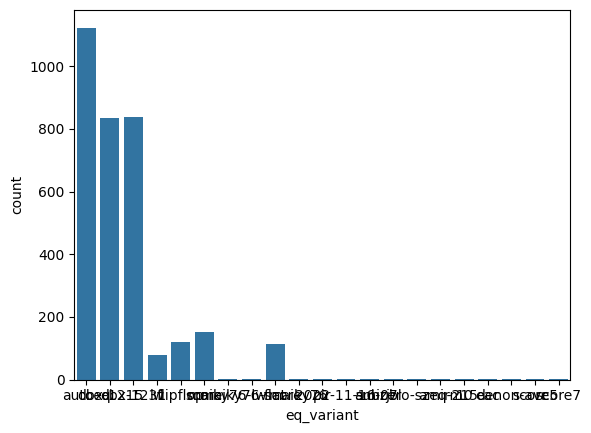

In [ ]:
# eq tipes
df["eq_variant"].value_counts()
sns.countplot(data=df, x="eq_variant")

In [ ]:
df.nlargest(10, "score_with_eq")[
    ["device_type", "score_with_eq"]
]

,device_type,score_with_eq
1400,speaker,8.81
1391,speaker,8.70
1065,speaker,8.59
1062,speaker,8.58
1056,speaker,8.51
1059,speaker,8.50
1236,speaker,8.32
2325,speaker,8.30
2001,speaker,8.19
1235,speaker,8.18


Text(0, 0.5, 'dB')

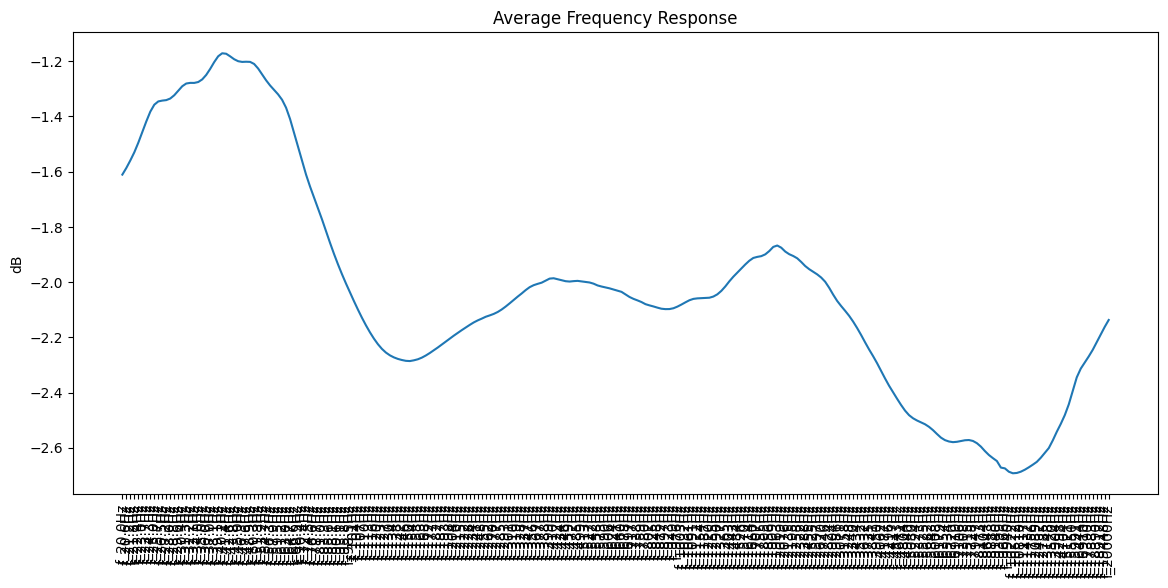

In [ ]:
mean_curve = df[freq_cols].mean()
plt.figure(figsize=(14,6))

plt.plot(freq_cols, mean_curve)

plt.xticks(rotation=90)
plt.title("Average Frequency Response")
plt.ylabel("dB")

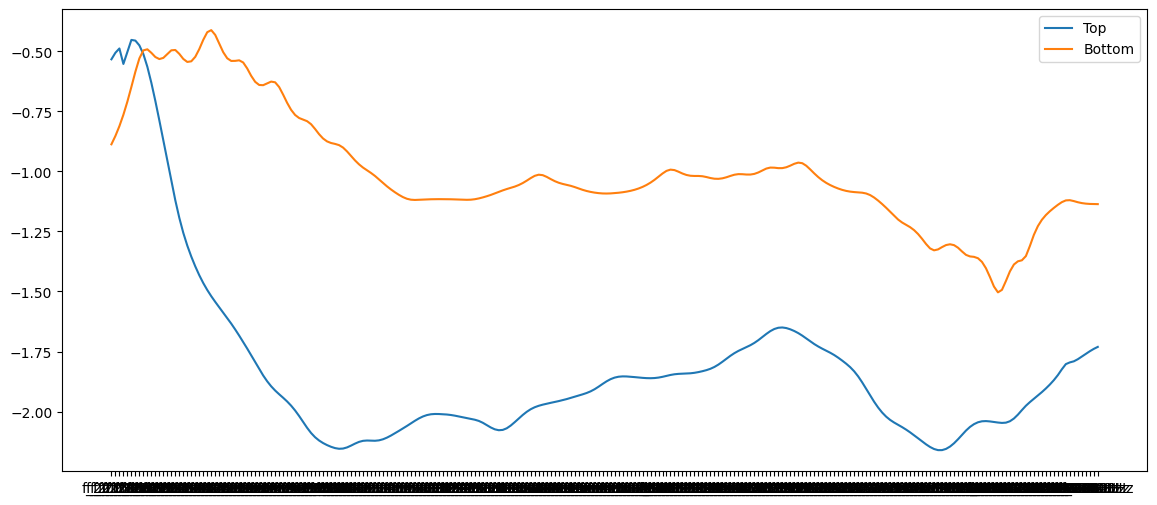

In [ ]:
top = df.nlargest(50, "score_with_eq")
bottom = df.nsmallest(50, "score_with_eq")

top_curve = top[freq_cols].mean()
bottom_curve = bottom[freq_cols].mean()

plt.figure(figsize=(14,6))

plt.plot(top_curve, label="Top")
plt.plot(bottom_curve, label="Bottom")

plt.legend()

Text(0.5, 1.0, 'Frequency Correlation with Score')

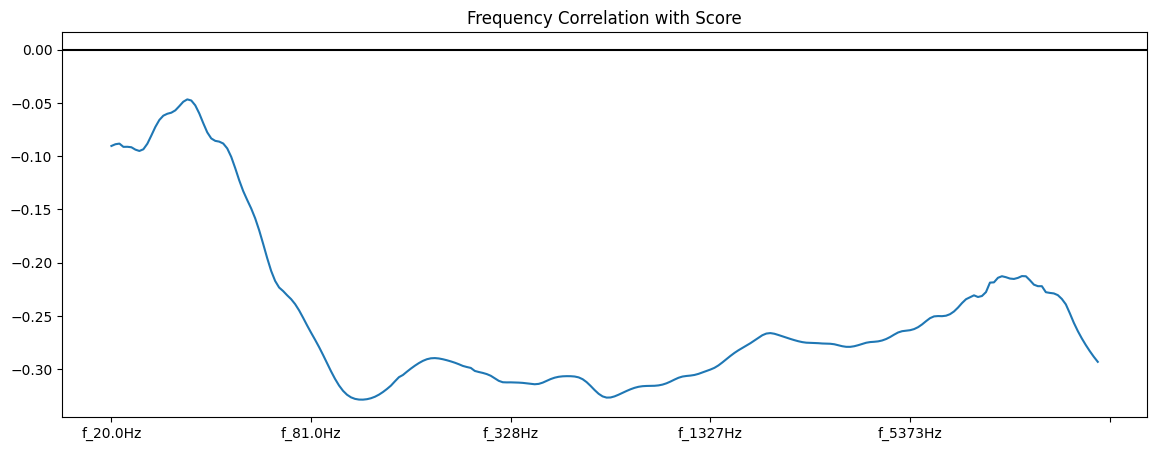

In [ ]:
corrs = []

for col in freq_cols:
    corr = df[col].corr(df["score_with_eq"])
    corrs.append(corr)

corrs = pd.Series(corrs, index=freq_cols)


plt.figure(figsize=(14,5))

corrs.plot()

plt.axhline(0, color="black")
plt.title("Frequency Correlation with Score")

<Axes: >

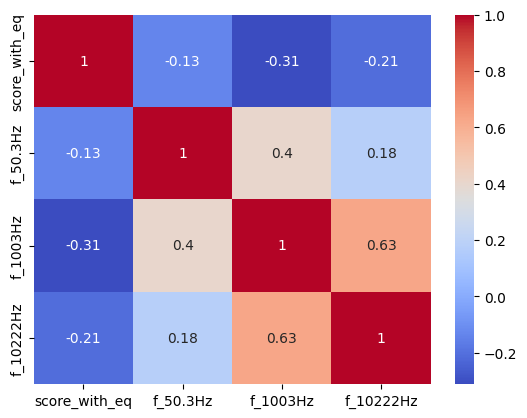

In [ ]:
selected = [
    "score_with_eq",
    "f_50.3Hz",
    "f_1003Hz",
    "f_10222Hz"
]

sns.heatmap(
    df[selected].corr(),
    annot=True,
    cmap="coolwarm"
)

# **EDA PARTE 2**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_speaker(speaker_name):

    freq_cols = [c for c in df.columns if c.startswith("f_")]

    freqs = np.array([
        float(c.replace("f_", "").replace("Hz", ""))
        for c in freq_cols
    ])

    # búsqueda flexible
    speaker_data = df[
        df["device_name"]
        .str.contains(speaker_name, case=False, na=False)
    ]

    if speaker_data.empty:
        print(f"No se encontró: {speaker_name}")
        return

    print("Matches encontrados:")
    print(speaker_data["device_name"].unique())

    row = speaker_data.iloc[0]

    response = row[freq_cols].values.astype(float)

    plt.figure(figsize=(15,6))

    plt.plot(
        freqs,
        response,
        linewidth=2,
        label=row["device_name"]
    )

    plt.xscale("log")

    plt.xlim(20, 20000)

    plt.xticks(
        [20,50,100,200,500,1000,2000,5000,10000,20000],
        ["20","50","100","200","500","1k","2k","5k","10k","20k"]
    )

    plt.axhline(0, color="black", linestyle="--")

    plt.grid(True, which="major", alpha=0.3)

    plt.legend()

    plt.title("Frequency Response")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (dB)")

    plt.show()

Matches encontrados:
['Presonus Eris E5 BT']


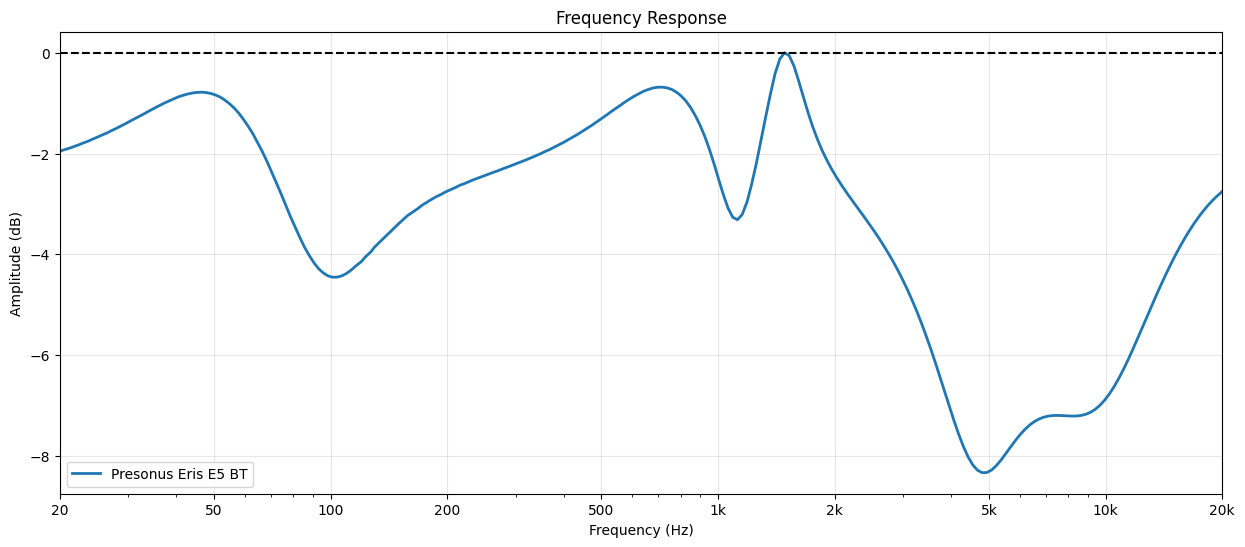

Matches encontrados:
['Mackie CR4']


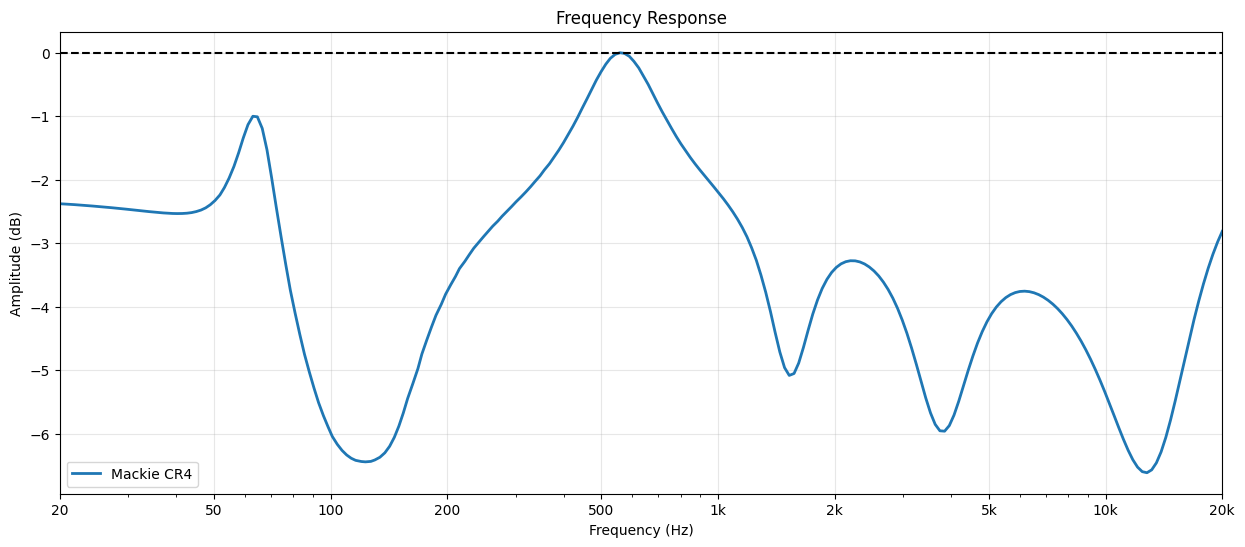

In [ ]:
plot_speaker("Eris E5 BT")
plot_speaker("CR4")